In [3]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

In [4]:
qm9 = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/qm9.csv")

In [5]:
qm9.describe()

,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
count,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000
mean,9.814382,1.406097,1.124921,2.706037,75.191296,-0.239977,0.011124,0.251100,1189.527450,0.148524,-411.543985,-411.535513,-411.534569,-411.577397,31.600676,-1750.812997,-1761.480647,-1771.546928,-1629.388196
std,1809.465666,1.583795,1.095618,1.530394,8.187793,0.022131,0.046936,0.047519,279.757172,0.033274,40.060230,40.060012,40.060012,40.060741,4.062471,239.313373,241.436103,243.151065,220.207088
min,0.000000,0.337120,0.331180,0.000000,6.310000,-0.428600,-0.175000,0.024600,19.000200,0.015951,-714.568061,-714.560153,-714.559209,-714.602138,6.002000,-2608.448864,-2626.408172,-2643.007040,-2417.121997
25%,2.554430,1.091630,0.910480,1.588700,70.380000,-0.252500,-0.023800,0.216300,1018.322600,0.125289,-437.913936,-437.905942,-437.904997,-437.947682,28.942000,-1904.772194,-1916.981009,-1928.181417,-1771.350603
50%,3.090360,1.369940,1.078560,2.500000,75.500000,-0.241000,0.012000,0.249400,1147.585800,0.148329,-417.864758,-417.857351,-417.856407,-417.895731,31.555000,-1753.464714,-1764.090324,-1774.151176,-1632.224955
75%,3.835820,1.653980,1.279540,3.636100,80.520000,-0.228700,0.049200,0.288200,1308.816600,0.171150,-387.049166,-387.039746,-387.038802,-387.083279,34.276000,-1596.871098,-1606.108658,-1615.066349,-1488.291333
max,619867.683140,437.903860,282.945450,29.556400,196.620000,-0.101700,0.193500,0.622100,3374.753200,0.273944,-40.478930,-40.476062,-40.475117,-40.498597,46.969000,-213.087624,-213.974294,-215.159658,-201.407171


In [6]:
print(qm9.isnull().values.any())

False


In [7]:
smiles = qm9[["smiles"]]
smiles.tail()

,smiles
133880,C1C2C3C4C5OC14C5N23
133881,C1N2C3C2C2C4OC12C34
133882,C1N2C3C4C5C2C13CN45
133883,C1N2C3C4C5CC13C2C45
133884,C1N2C3C4C5OC13C2C45


In [8]:
print(type(smiles.iloc[1500]))
print(smiles.iloc[1500])

<class 'pandas.core.series.Series'>
smiles    COCC(=O)C#N
Name: 1500, dtype: object


COCC(=O)C#N


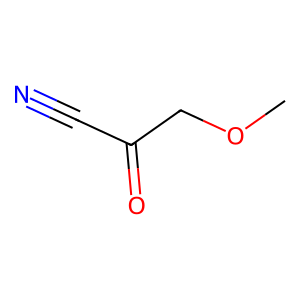

In [ ]:
mol = Chem.MolFromSmiles(smiles.iloc[1500].values[0])  

smiles = Chem.MolToSmiles(mol)
print(smiles)

# Save the SMILES string to a file
temp = smiles
if "#" in temp:
    temp = temp.replace("#", "%23")
with open("molecule.smiles", "w") as file:
    file.write(temp)

Draw.MolToImage(mol)